# Icosahedral Global Graph for Weather-Model-Graphs

This notebook demonstrates the complete pipeline for creating global spherical graphs using icosahedral meshes:

1. **Mesh generation** - Using trimesh to create hierarchical icosahedral meshes
2. **Graph construction** - Building mesh graphs with proper connectivity
3. **Grid-to-mesh connectivity** - Connecting input grid points to mesh nodes
4. **Integration with `create_all_graph_components`** - Using the main API

This approach provides quasi-uniform coverage of the sphere, avoiding the distortion problems of rectilinear grids in latitude/longitude space.

In [1]:
# Install required packages if not already installed
!pip install trimesh matplotlib pyproj networkx

In [2]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pyproj

In [3]:
from weather_model_graphs.create.mesh.layouts.icosahedral import (
    generate_icosahedral_mesh,  
    create_hierarchy_of_icosahedral_meshes,
    create_flat_icosahedral_mesh_graph,
    create_hierarchical_icosahedral_mesh_graph,
    connect_grid_to_mesh,
    lat_lon_to_cartesian,
    cartesian_to_lat_lon,
)

from weather_model_graphs.create import create_all_graph_components

## 1. Generate Icosahedral Mesh Hierarchy

First, let's generate a hierarchy of icosahedral meshes at different refinement levels.

In [4]:
# Generate mesh hierarchy
max_subdivisions = 3
mesh_list = create_hierarchy_of_icosahedral_meshes(max_subdivisions)

# Print statistics for each level
print("Icosahedral Mesh Hierarchy:")
print("-" * 50)
for level, (vertices, faces) in enumerate(mesh_list):
    print(f"Level {level}: {len(vertices):4d} nodes, {len(faces):5d} faces")
print("-" * 50)
print(f"Total nodes across all levels: {sum(len(v) for v, _ in mesh_list)}")

Icosahedral Mesh Hierarchy:
--------------------------------------------------
Level 0:   12 nodes,    20 faces
Level 1:   42 nodes,    80 faces
Level 2:  162 nodes,   320 faces
Level 3:  642 nodes,  1280 faces
--------------------------------------------------
Total nodes across all levels: 858


## 2. Create a Sample Global Grid

Let's create a regular latitude/longitude grid to represent our input data.

In [5]:
# Create a 2.5deg resolution global grid
resolution = 2.5
lats = np.arange(-90, 90.1, resolution)
lons = np.arange(-180, 180.1, resolution)
grid_lat, grid_lon = np.meshgrid(lats, lons, indexing='ij')
grid_lat_lon = np.column_stack([grid_lat.ravel(), grid_lon.ravel()])

print(f"Grid resolution: {resolution}deg")
print(f"Grid dimensions: {len(lats)} latitudes x {len(lons)} longitudes")
print(f"Total grid nodes: {len(grid_lat_lon)}")

Grid resolution: 2.5deg
Grid dimensions: 73 latitudes x 145 longitudes
Total grid nodes: 10585


## 3. Connect Grid to Mesh (G2M)

Now connect each grid point to nearby mesh nodes using radius-based search.

In [6]:
# Use finest mesh for grid connections
finest_vertices, finest_faces = mesh_list[-1]

# Connect grid to mesh
g2m_edges = connect_grid_to_mesh(
    grid_lat_lon, 
    finest_vertices, 
    finest_faces,
    radius_factor=0.6  # Connection radius relative to max edge length
)

print(f"Grid-to-mesh connections: {g2m_edges.shape[1]}")
print(f"Average connections per grid node: {g2m_edges.shape[1]/len(grid_lat_lon):.2f}")
print(f"Average connections per mesh node: {g2m_edges.shape[1]/len(finest_vertices):.2f}")

Grid-to-mesh connections: 16617
Average connections per grid node: 1.57
Average connections per mesh node: 25.88


## 4. Create Mesh Graphs

We can create either flat (single-level) or hierarchical (multi-level) mesh graphs.

In [7]:
# Flat mesh graph (single level)
G_flat = create_flat_icosahedral_mesh_graph(subdivisions=3)
print("Flat mesh graph:")
print(f"  Nodes: {len(G_flat.nodes)}")
print(f"  Edges: {len(G_flat.edges)}")
print()

# Hierarchical mesh graph (multiple levels with inter-level connections)
G_hier = create_hierarchical_icosahedral_mesh_graph(max_subdivisions=3)
print("Hierarchical mesh graph:")
print(f"  Total nodes: {len(G_hier.nodes)}")
print(f"  Total edges: {len(G_hier.edges)}")

# Count nodes per level
level_counts = {}
for node, data in G_hier.nodes(data=True):
    level = data.get('level', 0)
    level_counts[level] = level_counts.get(level, 0) + 1

print("\nNodes per level:")
for level in sorted(level_counts.keys()):
    print(f"  Level {level}: {level_counts[level]} nodes")

Flat mesh graph:
  Nodes: 642
  Edges: 3840

Hierarchical mesh graph:
  Total nodes: 858
  Total edges: 8052

Nodes per level:
  Level 0: 12 nodes
  Level 1: 42 nodes
  Level 2: 162 nodes
  Level 3: 642 nodes


## 5. Visualize the Mesh and Connections

Let's visualize the icosahedral mesh and its connections to the grid.

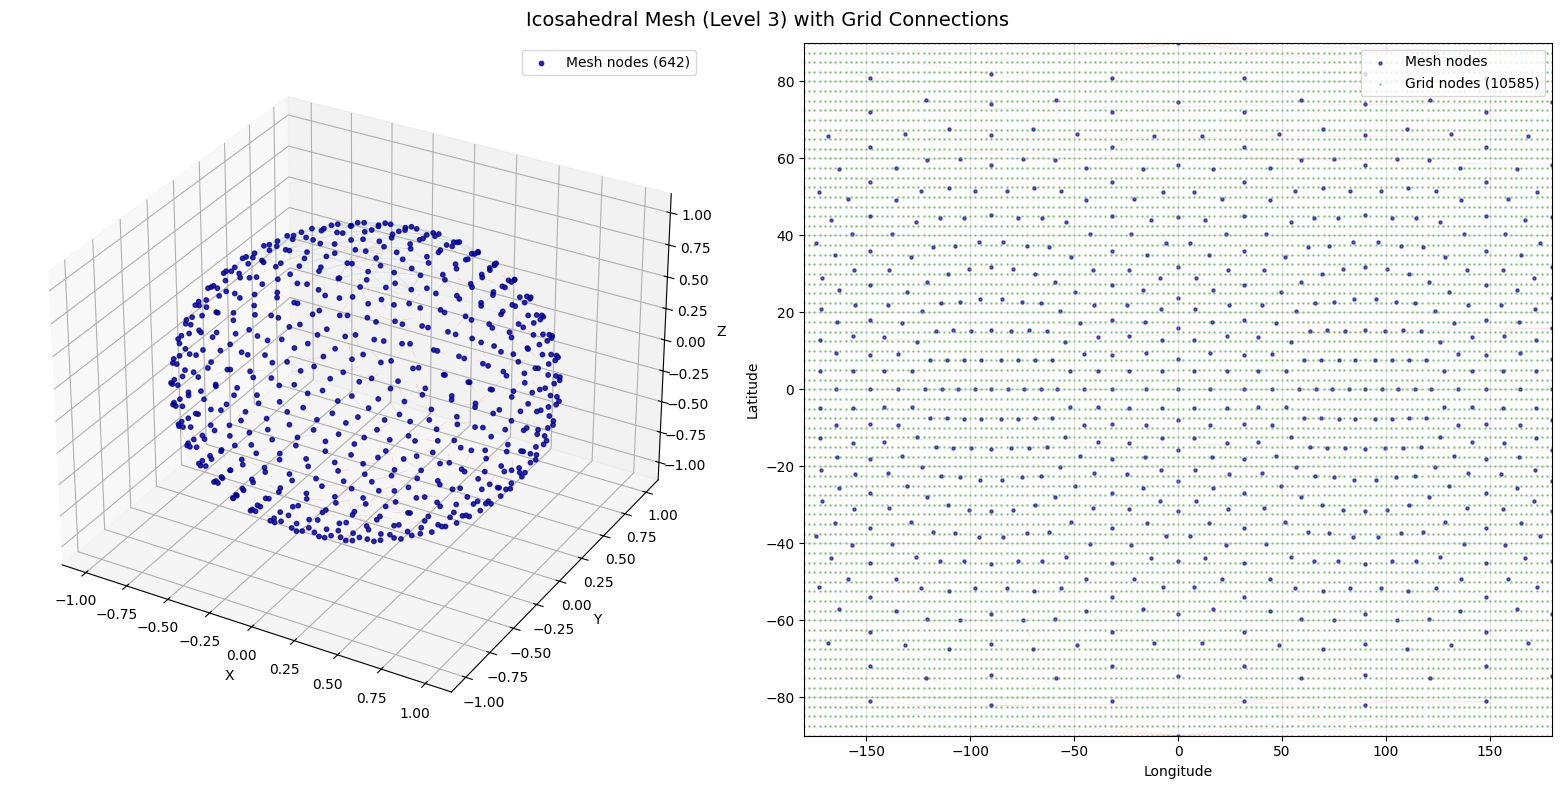

In [8]:
def plot_icosahedral_graph(vertices, faces, g2m_edges=None, grid_lat_lon=None, 
                           title=None, max_edges_to_plot=500):
    """Plot icosahedral mesh with optional grid connections."""
    fig = plt.figure(figsize=(16, 8))
    
    # 3D Plot
    ax1 = fig.add_subplot(121, projection='3d')
    
    # Plot mesh edges
    for face in faces[:100]:  # Plot subset for clarity
        for i, j in [(0,1), (1,2), (2,0)]:
            ax1.plot3D(*zip(vertices[face[i]], vertices[face[j]]), 
                      color='lightblue', alpha=0.3, linewidth=0.5)
    
    # Plot mesh nodes
    ax1.scatter(vertices[:, 0], vertices[:, 1], vertices[:, 2], 
                c='darkblue', s=10, label=f'Mesh nodes ({len(vertices)})', alpha=0.8)
    
    # Plot grid-to-mesh connections if provided
    if g2m_edges is not None and grid_lat_lon is not None:
        # Sample connections for clarity
        step = max(1, g2m_edges.shape[1] // max_edges_to_plot)
        for i in range(0, g2m_edges.shape[1], step):
            grid_idx, mesh_idx = g2m_edges[0, i], g2m_edges[1, i]
            grid_cart = lat_lon_to_cartesian(
                np.array([grid_lat_lon[grid_idx, 0]]), 
                np.array([grid_lat_lon[grid_idx, 1]])
            )[0]
            ax1.plot3D(*zip(grid_cart, vertices[mesh_idx]), 
                       color='red', alpha=0.2, linewidth=0.3)
    
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('Z')
    ax1.legend(loc='upper right')
    
    # 2D Projection
    ax2 = fig.add_subplot(122)
    
    # Convert mesh vertices to lat/lon
    mesh_lat_lon = cartesian_to_lat_lon(vertices)
    
    # Plot mesh nodes
    ax2.scatter(mesh_lat_lon[:, 1], mesh_lat_lon[:, 0], 
                c='darkblue', s=5, label='Mesh nodes', alpha=0.6)
    
    # Plot grid nodes if provided
    if grid_lat_lon is not None:
        ax2.scatter(grid_lat_lon[:, 1], grid_lat_lon[:, 0], 
                    c='green', s=1, label=f'Grid nodes ({len(grid_lat_lon)})', alpha=0.3)
    
    # Plot connections in 2D
    if g2m_edges is not None and grid_lat_lon is not None:
        step = max(1, g2m_edges.shape[1] // max_edges_to_plot)
        for i in range(0, g2m_edges.shape[1], step):
            grid_idx, mesh_idx = g2m_edges[0, i], g2m_edges[1, i]
            grid_lon, grid_lat = grid_lat_lon[grid_idx, 1], grid_lat_lon[grid_idx, 0]
            mesh_lon, mesh_lat = mesh_lat_lon[mesh_idx, 1], mesh_lat_lon[mesh_idx, 0]
            ax2.plot([grid_lon, mesh_lon], [grid_lat, mesh_lat], 
                     color='red', alpha=0.15, linewidth=0.3)
    
    ax2.set_xlabel('Longitude')
    ax2.set_ylabel('Latitude')
    ax2.set_xlim(-180, 180)
    ax2.set_ylim(-90, 90)
    ax2.grid(True, alpha=0.3)
    ax2.legend(loc='upper right')
    
    if title:
        fig.suptitle(title, fontsize=14)
    
    plt.tight_layout()
    return fig, (ax1, ax2)


# Plot the finest mesh with grid connections
fig, axes = plot_icosahedral_graph(
    finest_vertices, 
    finest_faces, 
    g2m_edges, 
    grid_lat_lon,
    title=f"Icosahedral Mesh (Level {max_subdivisions}) with Grid Connections"
)
plt.show()

## 6. Integration with `create_all_graph_components`

Now let's use the main API to create a complete graph with icosahedral mesh.

In [9]:
# Define geographic CRS (WGS84)
geographic_crs = pyproj.CRS.from_string("EPSG:4326")

# Create complete graph with flat icosahedral mesh
G_complete = create_all_graph_components(
    coords=grid_lat_lon,
    m2m_connectivity="icosahedral",
    m2m_connectivity_kwargs={
        "subdivisions": 3,  # Mesh refinement level
        "hierarchical": False,  # Flat mesh (single level)
        "radius": 1.0,  # Sphere radius
    },
    m2g_connectivity="within_radius",
    g2m_connectivity_kwargs={"rel_max_dist": 0.6},
    m2g_connectivity_kwargs={"rel_max_dist": 0.6},
    coords_crs=geographic_crs,
    graph_crs=geographic_crs,
    g2m_connectivity="within_radius",        
)

print("Complete graph statistics:")
print(f"  Total nodes: {len(G_complete.nodes)}")
print(f"  Total edges: {len(G_complete.edges)}")

# Count nodes by type
node_types = {}
for node, data in G_complete.nodes(data=True):
    node_type = data.get('type', 'unknown')
    node_types[node_type] = node_types.get(node_type, 0) + 1

print("\nNodes by type:")
for node_type, count in node_types.items():
    print(f"  {node_type}: {count}")

# Count edges by component
edge_components = {}
for u, v, data in G_complete.edges(data=True):
    component = data.get('component', 'unknown')
    edge_components[component] = edge_components.get(component, 0) + 1

print("\nEdges by component:")
for component, count in edge_components.items():
    print(f"  {component}: {count}")

2026-03-01 18:07:40.527 | DEBUG    | weather_model_graphs.create.base:create_all_graph_components:118 - Projecting coords from CRS(EPSG:4326) to CRS(EPSG:4326) for graph creation.


Complete graph statistics:
  Total nodes: 11227
  Total edges: 20463

Nodes by type:
  mesh: 642
  grid: 10585

Edges by component:
  m2m: 3840
  m2g: 16617
  g2m: 6


In [10]:
from weather_model_graphs.create.mesh.layouts.icosahedral import generate_icosahedral_mesh
create_icosahedral_mesh = generate_icosahedral_mesh

# Then run the hierarchical example
G_hier_complete = create_all_graph_components(
    coords=grid_lat_lon,
    m2m_connectivity="icosahedral",
    m2m_connectivity_kwargs={
        "max_subdivisions": 3,
        "hierarchical": True,
        "radius": 1.0,
    },
    m2g_connectivity="within_radius",
    g2m_connectivity="within_radius",
    m2g_connectivity_kwargs={"rel_max_dist": 0.6},
    g2m_connectivity_kwargs={"rel_max_dist": 0.6},
    coords_crs=geographic_crs,
    graph_crs=geographic_crs,
)

2026-03-01 18:07:42.073 | DEBUG    | weather_model_graphs.create.base:create_all_graph_components:118 - Projecting coords from CRS(EPSG:4326) to CRS(EPSG:4326) for graph creation.


## 7. Hierarchical Mesh Example

Create a graph with hierarchical (multi-level) icosahedral mesh.

In [11]:
# Create hierarchical graph with multiple mesh levels
G_hier_complete = create_all_graph_components(
    coords=grid_lat_lon,
    m2m_connectivity="icosahedral",
    m2m_connectivity_kwargs={
        "max_subdivisions": 3,  # Maximum refinement level
        "hierarchical": True,  # Enable hierarchy
        "radius": 1.0,
    },
    m2g_connectivity="within_radius",
    m2g_connectivity_kwargs={
        "max_dist": 0.5,
    },
    g2m_connectivity="within_radius",
    g2m_connectivity_kwargs={
        "max_dist": 0.5,
    },
    coords_crs=geographic_crs,
    graph_crs=geographic_crs,
)

print("Hierarchical graph statistics:")
print(f"  Total nodes: {len(G_hier_complete.nodes)}")
print(f"  Total edges: {len(G_hier_complete.edges)}")

# Count mesh nodes by level
mesh_levels = {}
for node, data in G_hier_complete.nodes(data=True):
    if data.get('type') == 'mesh':
        level = data.get('level', 0)
        mesh_levels[level] = mesh_levels.get(level, 0) + 1

print("\nMesh nodes by level:")
for level in sorted(mesh_levels.keys()):
    print(f"  Level {level}: {mesh_levels[level]} nodes")

2026-03-01 18:07:43.484 | DEBUG    | weather_model_graphs.create.base:create_all_graph_components:118 - Projecting coords from CRS(EPSG:4326) to CRS(EPSG:4326) for graph creation.


Hierarchical graph statistics:
  Total nodes: 11443
  Total edges: 15518

Mesh nodes by level:
  Level 0: 12 nodes
  Level 1: 42 nodes
  Level 2: 162 nodes
  Level 3: 642 nodes


## 8. Visualize Graph Components

Let's visualize the different components of our graph.

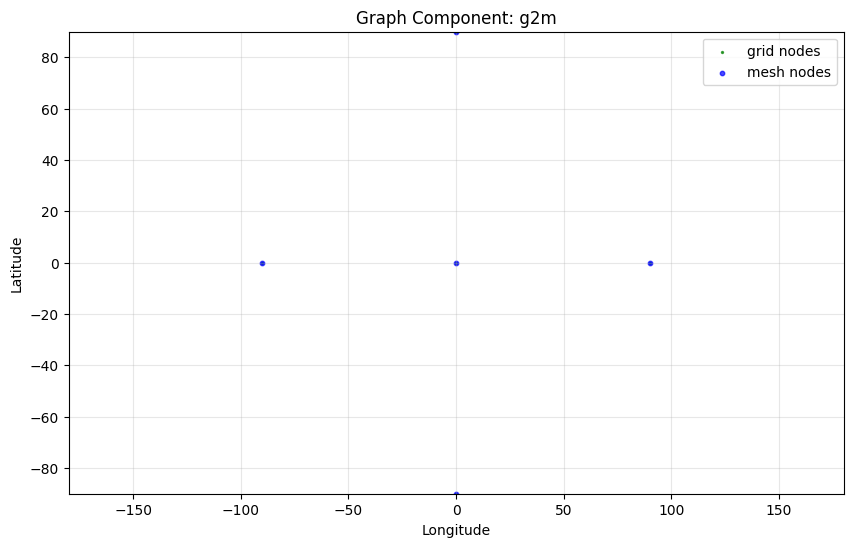

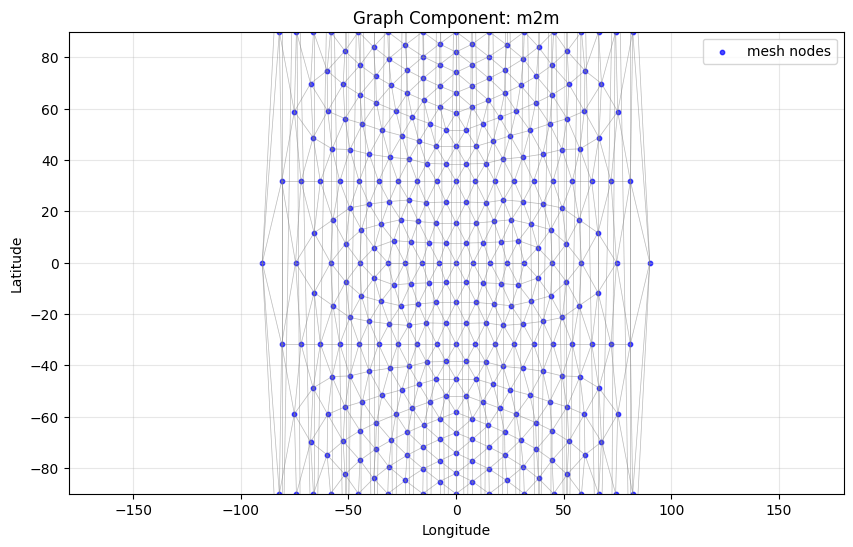

c:\Users\Admin\miniconda3\envs\wmg\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


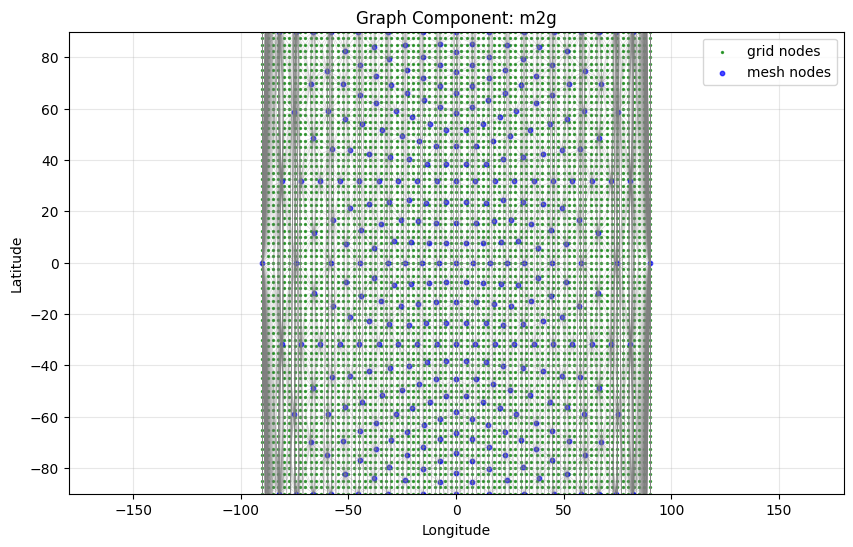

In [12]:
def plot_graph_component(G, component_name, title=None):
    """Plot a specific component of the graph."""
    # Extract subgraph for this component
    edges = [(u, v) for u, v, d in G.edges(data=True) 
             if d.get('component') == component_name]
    
    if not edges:
        print(f"No edges found for component '{component_name}'")
        return
    
    G_sub = G.edge_subgraph(edges).copy()
    
    # Collect positions for plotting
    pos_2d = {}
    node_types = {}
    
    for node in G_sub.nodes:
        data = G.nodes[node]
        if 'lat' in data and 'lon' in data:
            pos_2d[node] = (data['lon'], data['lat'])
        elif 'pos' in data:
            # Convert cartesian to lat/lon if needed
            if data['pos'].shape == (3,):
                lat_lon = cartesian_to_lat_lon(data['pos'].reshape(1, 3))[0]
                pos_2d[node] = (lat_lon[1], lat_lon[0])
            else:
                pos_2d[node] = (data['pos'][0], data['pos'][1])
        
        node_types[node] = data.get('type', 'unknown')
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot edges
    for u, v in G_sub.edges():
        if u in pos_2d and v in pos_2d:
            ax.plot([pos_2d[u][0], pos_2d[v][0]], 
                    [pos_2d[u][1], pos_2d[v][1]], 
                    'gray', alpha=0.3, linewidth=0.5)
    
    # Plot nodes by type
    colors = {'mesh': 'blue', 'grid': 'green', 'unknown': 'red'}
    for node_type in set(node_types.values()):
        nodes = [n for n in G_sub.nodes if node_types[n] == node_type]
        if nodes:
            x = [pos_2d[n][0] for n in nodes]
            y = [pos_2d[n][1] for n in nodes]
            ax.scatter(x, y, c=colors.get(node_type, 'black'), 
                      s=10 if node_type == 'mesh' else 2, 
                      label=f'{node_type} nodes', alpha=0.7)
    
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_xlim(-180, 180)
    ax.set_ylim(-90, 90)
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    if title:
        ax.set_title(title)
    else:
        ax.set_title(f"Graph Component: {component_name}")
    
    return fig, ax


# Plot each component
for component in ['g2m', 'm2m', 'm2g']:
    fig, ax = plot_graph_component(G_complete, component)
    plt.show()

## 9. Performance and Scaling

Let's examine how the mesh size scales with subdivision level.

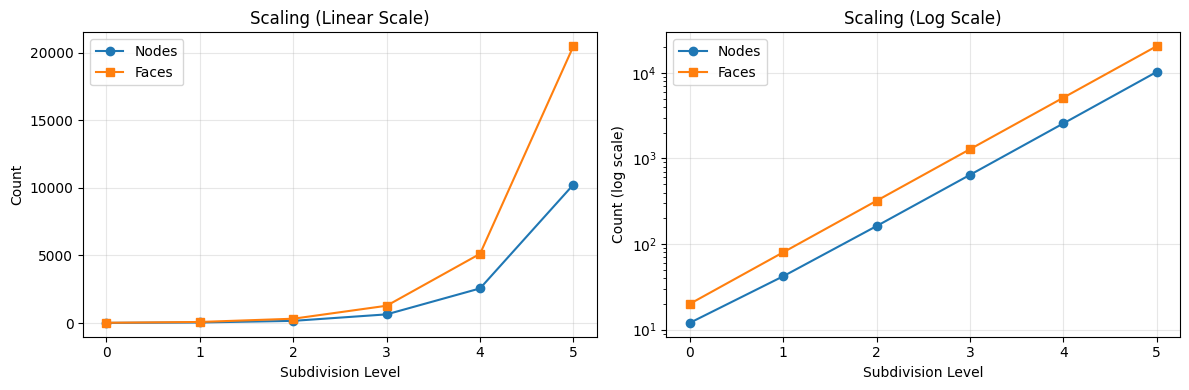


Growth rate:
Level 0 -> 1: 3.50x (theoretical: 4x)
Level 1 -> 2: 3.86x (theoretical: 4x)
Level 2 -> 3: 3.96x (theoretical: 4x)
Level 3 -> 4: 3.99x (theoretical: 4x)
Level 4 -> 5: 4.00x (theoretical: 4x)


In [13]:
# Analyze scaling behavior
subdivisions = np.arange(0, 6)
node_counts = []
face_counts = []

for s in subdivisions:
    v, f = generate_icosahedral_mesh(refinement_level=s)
    node_counts.append(len(v))
    face_counts.append(len(f))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Linear scale
ax1.plot(subdivisions, node_counts, 'o-', label='Nodes')
ax1.plot(subdivisions, face_counts, 's-', label='Faces')
ax1.set_xlabel('Subdivision Level')
ax1.set_ylabel('Count')
ax1.set_title('Scaling (Linear Scale)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Log scale
ax2.semilogy(subdivisions, node_counts, 'o-', label='Nodes')
ax2.semilogy(subdivisions, face_counts, 's-', label='Faces')
ax2.set_xlabel('Subdivision Level')
ax2.set_ylabel('Count (log scale)')
ax2.set_title('Scaling (Log Scale)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nGrowth rate:")
for i in range(1, len(subdivisions)):
    ratio = node_counts[i] / node_counts[i-1]
    print(f"Level {i-1} -> {i}: {ratio:.2f}x (theoretical: 4x)")

## 10. Save and Load Graph

Finally, let's save our graph for later use.

In [14]:
import pickle
import os

# Create directory for saving graphs
os.makedirs('saved_graphs', exist_ok=True)

# Save the complete graph
with open('saved_graphs/icosahedral_graph.pkl', 'wb') as f:
    pickle.dump(G_complete, f)

print("Graph saved to 'saved_graphs/icosahedral_graph.pkl'")

# Load it back
with open('saved_graphs/icosahedral_graph.pkl', 'rb') as f:
    G_loaded = pickle.load(f)

print(f"\nLoaded graph: {len(G_loaded.nodes)} nodes, {len(G_loaded.edges)} edges")

Graph saved to 'saved_graphs/icosahedral_graph.pkl'

Loaded graph: 11227 nodes, 20463 edges
